# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 01 – Descreva o racional da sua resposta:

R.: Importei o dataframe .csv e determinei a frequência do número de caracteres. Após, inseri uma coluna na dataframe com esses valores. Com esses valores, usei o matplotlib para criar o gráfico de barras onde o eixo X = número de caracteres e eixo Y = frequência. 

## 02 – Desenhe o fluxograma da resposta:

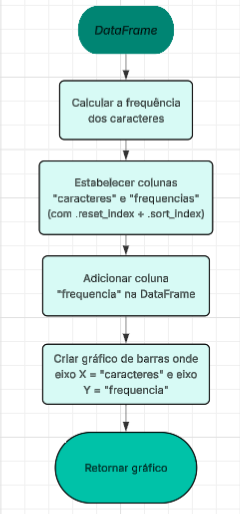

## 03 – Escreva o programa em Python:

In [116]:
import pandas as pd

In [117]:
df_genes = pd.read_csv("df_genes.csv", index_col=0, header=0)
df_genes

,caracteres,dois_primeiros,contagem_a,tem_hu
TNF-alpha,9,TN,2,False
IL-6,4,IL,0,False
BRCA1,5,BR,0,False
LAMB3,5,LA,0,False
HDAC1,5,HD,0,False


In [118]:
tab_frequencia = df_genes["caracteres"].value_counts().sort_index()
print(tab_frequencia)
tab_frequencia = tab_frequencia.reset_index()
tab_frequencia.columns = ["caracteres", "frequencia"]
print(tab_frequencia)

caracteres
4    1
5    3
9    1
Name: count, dtype: int64
   caracteres  frequencia
0           4           1
1           5           3
2           9           1


In [119]:
df_genes = df_genes.merge(tab_frequencia, on="caracteres", how="left")
df_genes

,caracteres,dois_primeiros,contagem_a,tem_hu,frequencia
0,9,TN,2,False,1
1,4,IL,0,False,1
2,5,BR,0,False,3
3,5,LA,0,False,3
4,5,HD,0,False,3


In [120]:
import matplotlib.pyplot as plt

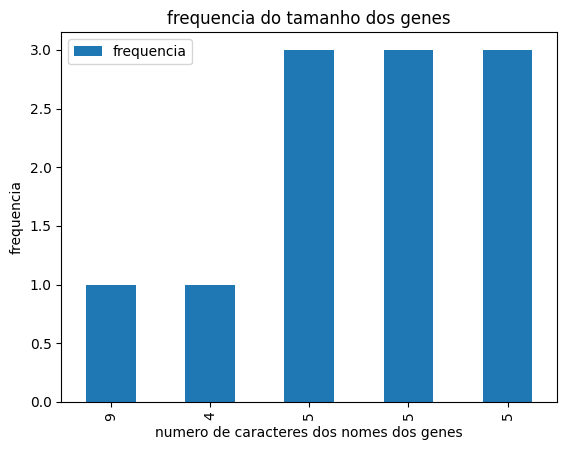

In [121]:
df_genes.plot(x="caracteres", y="frequencia", kind="bar")
plt.xlabel("numero de caracteres dos nomes dos genes")
plt.ylabel("frequencia")
plt.title("frequencia do tamanho dos genes")
plt.show()

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

R.: O racional segue o mesmo do exercício anterior, como não precisava considerar a ordem dos genes, utilizai o método '.sort_index()' pra organizar a tabela de frequência pelo número de caracteres. Nesse exercício, a ordem deve ser preservada, então o método não é usado. Por fim, o gráfico é feito da mesma forma, mantendo a ordem estabelecida.

## 05 – Desenhe o fluxograma da resposta:

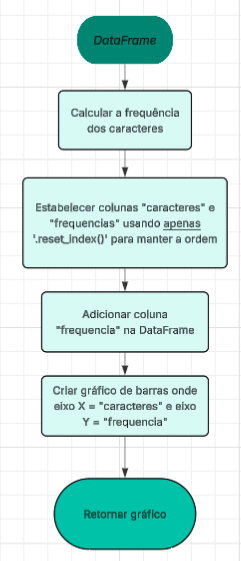

## 06 – Escreva o programa em Python:

In [122]:
df_genes = pd.read_csv("df_genes.csv", index_col=0, header=0)
df_genes

,caracteres,dois_primeiros,contagem_a,tem_hu
TNF-alpha,9,TN,2,False
IL-6,4,IL,0,False
BRCA1,5,BR,0,False
LAMB3,5,LA,0,False
HDAC1,5,HD,0,False


In [123]:
tab_frequencia = df_genes["caracteres"].value_counts().reset_index()
tab_frequencia.columns = ["caracteres", "frequencia"]

In [124]:
df_genes = df_genes.merge(tab_frequencia, on="caracteres", how="left")
df_genes

,caracteres,dois_primeiros,contagem_a,tem_hu,frequencia
0,9,TN,2,False,1
1,4,IL,0,False,1
2,5,BR,0,False,3
3,5,LA,0,False,3
4,5,HD,0,False,3


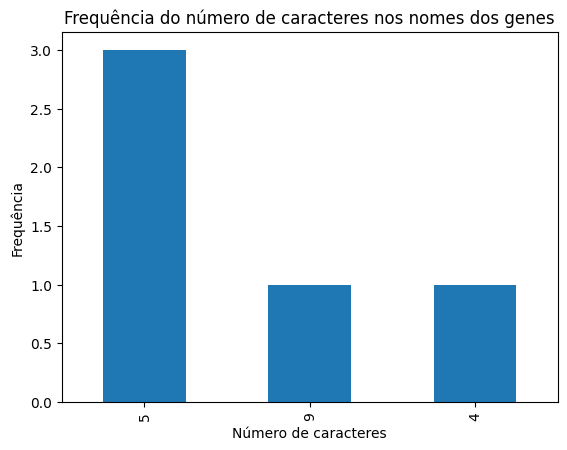

In [125]:
df_genes["caracteres"].value_counts().plot(kind="bar")
plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.title("Frequência do número de caracteres nos nomes dos genes")
plt.show()

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [126]:
df_genes

,caracteres,dois_primeiros,contagem_a,tem_hu,frequencia
0,9,TN,2,False,1
1,4,IL,0,False,1
2,5,BR,0,False,3
3,5,LA,0,False,3
4,5,HD,0,False,3


In [127]:
df_genes = df_genes.drop(columns=["dois_primeiros", "contagem_a", "tem_hu"])

df_genes = df_genes.rename(columns={
    "caracteres": "Número de Caracteres",
    "frequencia": "Frequência"
})

df_genes["Amostra"] = "Amostra 1"
print(df_genes)

   Número de Caracteres  Frequência    Amostra
0                     9           1  Amostra 1
1                     4           1  Amostra 1
2                     5           3  Amostra 1
3                     5           3  Amostra 1
4                     5           3  Amostra 1


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [128]:
import numpy as np

In [129]:
array_8 = np.random.randint(1,10,5)
array_8

array([8, 6, 7, 6, 8], dtype=int32)

In [130]:
tab_freq2 = pd.Series(array_8).value_counts().reset_index()
tab_freq2.columns = ["Número de Caracteres", "Frequência"]
print(tab_freq2)

   Número de Caracteres  Frequência
0                     8           2
1                     6           2
2                     7           1


In [131]:
df_genes["Amostra 2"] = array_8
print(df_genes)

   Número de Caracteres  Frequência    Amostra  Amostra 2
0                     9           1  Amostra 1          8
1                     4           1  Amostra 1          6
2                     5           3  Amostra 1          7
3                     5           3  Amostra 1          6
4                     5           3  Amostra 1          8


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [132]:
amostra3 = np.random.randint(1, 10, len(df_genes))
amostra4 = np.random.randint(1, 10, len(df_genes))
amostra5 = np.random.randint(1, 10, len(df_genes))
amostra6 = np.random.randint(1, 10, len(df_genes))

In [133]:
df_genes["Amostra 3"] = amostra3
df_genes["Amostra 4"] = amostra4
df_genes["Amostra 5"] = amostra5
df_genes["Amostra 6"] = amostra6
print(df_genes)

   Número de Caracteres  Frequência    Amostra  Amostra 2  Amostra 3  \
0                     9           1  Amostra 1          8          7   
1                     4           1  Amostra 1          6          2   
2                     5           3  Amostra 1          7          2   
3                     5           3  Amostra 1          6          2   
4                     5           3  Amostra 1          8          1   

   Amostra 4  Amostra 5  Amostra 6  
0          4          5          7  
1          3          9          5  
2          3          2          5  
3          3          1          5  
4          5          8          5  


## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

In [134]:
df_genes["Amostra 7"] = np.random.randint(1, 10, len(df_genes))
df_genes["Amostra 8"] = np.random.randint(1, 10, len(df_genes))
df_genes["Amostra 9"] = np.random.randint(1, 10, len(df_genes))

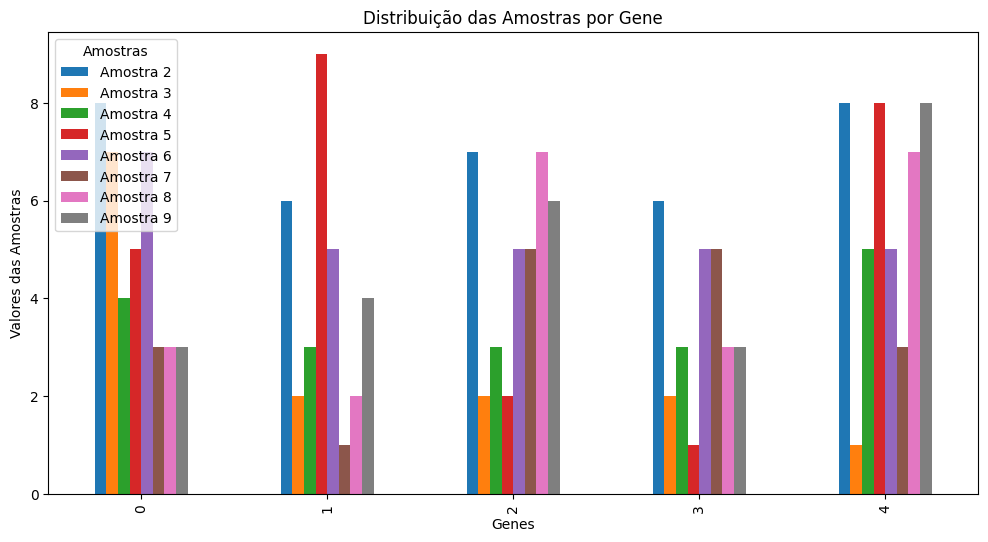

In [135]:
df_genes[["Amostra","Amostra 2","Amostra 3","Amostra 4",
          "Amostra 5","Amostra 6","Amostra 7","Amostra 8","Amostra 9"]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Distribuição das Amostras por Gene")
plt.xlabel("Genes")
plt.ylabel("Valores das Amostras")
plt.legend(title="Amostras")
plt.show()